# Session 3 — Demo 2: Two warehouses, two verdicts

**What this demo covers.** A second warehouse — **BRAVO** — enters the story: same week, same processes, same schema, different site. We build an operations scoreboard, then bring in **money** — and watch the verdict flip. The lesson: *choosing the metric is a decision, not a formality.*

Same four steps as Demo 1 on every block: ❓ question → 🔍 what we'll do → ✅ what it means → ⛔ what it does not mean.

**Data.** `data/alpha/` and `data/bravo/` — [data dictionary](../../data/README.md). Ids are local to each site: join within a warehouse, never across.

**How to run.** Locally: top to bottom. Colab: uncomment the lines in the setup cell.

## 0. Setup

In [1]:
import pickle
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator

# both warehouses live under data/
DATA = Path("../../data")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib seaborn

In [2]:
# the two helpers from Demo 1 travel with us
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid."""
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)


def human_format(num):
    """1234567 -> '1.23M'."""
    for unit in ["", "K", "M", "B"]:
        if abs(num) < 1000:
            return f"{num:.3g}{unit}"
        num /= 1000
    return f"{num:.3g}T"


# one colour per site, used consistently in every chart below
ALPHA_COLOR, BRAVO_COLOR = "tab:blue", "tab:orange"

## 1. Load both sites

Two folders, one schema — a perfect job for a small **function** (the primer pays off). Note the name: a function *does* something, so it reads as a verb — `load_site`, not `site_loader`.

In [3]:
def load_site(name):
    """One warehouse: events, its own reference tables, its metadata."""
    folder = DATA / name
    return {
        "events": pd.read_parquet(folder / "picking_events.parquet"),
        "prices": pd.read_parquet(folder / "item_prices.parquet"),
        "info": pickle.loads((folder / "warehouse_info.pickle").read_bytes()),
    }

alpha = load_site("alpha")
bravo = load_site("bravo")
print("ALPHA:", alpha["info"]["period"], "   BRAVO:", bravo["info"]["period"])

ALPHA: {'from': '2026-03-02', 'to': '2026-03-08'}    BRAVO: {'from': '2026-03-02', 'to': '2026-03-08'}


> 🤖 **Ask the assistant.** Ask it to write a function that loads one warehouse folder into a dictionary of tables. Read what comes back line by line against ours. The names will differ; the checks must not: the period printed, both sites loaded the same way.

Same week — the comparison is fair on time.

Both sites need the same per-task table we built in Demo 1, so that gets its own verb-named function too. Writing it once means the two sites are measured *identically* — the most common way comparisons go wrong is that each side is computed slightly differently.

In [4]:
def build_task_table(site):
    """One row per finished, non-empty task: start, end, picks, duration, pace."""
    events = site["events"]
    picks = events[events["event_type"] == "PickCorrectItem"]

    tasks = (
        events
        .groupby("task_id")
        .agg(
            start=("event_time", "min"),
            end=("event_time", "max"),
        )
    )
    tasks["picks"] = picks.groupby("task_id").size()

    finished_ids = set(events.loc[events["event_type"] == "FinishTask", "task_id"])
    tasks = tasks[tasks.index.isin(finished_ids) & (tasks["picks"] > 0)]

    tasks["duration_min"] = (tasks["end"] - tasks["start"]).dt.total_seconds() / 60
    tasks["picks_per_hour"] = tasks["picks"] / (tasks["duration_min"] / 60)
    return tasks


alpha_tasks = build_task_table(alpha)
bravo_tasks = build_task_table(bravo)

print(f"tasks kept — ALPHA: {len(alpha_tasks):,}   BRAVO: {len(bravo_tasks):,}")

tasks kept — ALPHA: 4,077   BRAVO: 2,397


## 2. ❓ "Which site runs better?"

<details>
<summary>🔍 <b>What we'll do</b> — think first, then open</summary>

put six operational metrics side by side — volume, quality, staffing, productivity, and two pace numbers.
</details>

In [5]:
def build_ops_row(site, tasks):
    """The six headline operational metrics for one site."""
    events = site["events"]
    picks = events[events["event_type"] == "PickCorrectItem"]
    wrong_picks = events[events["event_type"] == "PickWrongItem"]
    workers = events["user_id"].nunique()
    scan_attempts = len(wrong_picks) + len(picks)

    return {
        "successful picks": len(picks),
        "wrong-scan share, %": round(100 * len(wrong_picks) / scan_attempts, 1),
        "workers": workers,
        "picks per worker": round(len(picks) / workers),
        "median task duration, min": round(tasks["duration_min"].median(), 1),
        "median picks per hour": round(tasks["picks_per_hour"].median(), 1),
    }


alpha_ops = build_ops_row(alpha, alpha_tasks)
bravo_ops = build_ops_row(bravo, bravo_tasks)

# dtype=object keeps the counts as whole numbers next to the rows with decimals
scoreboard = pd.DataFrame({
    "ALPHA": pd.Series(alpha_ops, dtype=object),
    "BRAVO": pd.Series(bravo_ops, dtype=object),
})
scoreboard

,ALPHA,BRAVO
successful picks,145904,88074
"wrong-scan share, %",18.6,26.8
workers,82,66
picks per worker,1779,1334
"median task duration, min",15.9,20.9
median picks per hour,125.9,98.6


✅ **What it means:** six operational metrics, one verdict — **BRAVO loses every row.** A quarter of its pick scans are wrong, its people pick ~25% less per person, and its typical task runs at ~22% fewer picks per hour.

⛔ **What it does NOT mean:** that ALPHA is the better warehouse. Six metrics all pointing one way is persuasive, but every one of them is an *operations* metric. Nobody has mentioned money yet. Hold the verdict.

> 🤖 **Ask the assistant.** Ask it to add a row `median task duration, min` to the scoreboard. Then verify its two numbers against Demo 1 (ALPHA 15.9). A row you cannot verify is not a row.

---

## 3. ❓ "Are BRAVO's pickers actually slower, or is it just the average?"

<details>
<summary>🔍 <b>What we'll do</b> — think first, then open</summary>

stop comparing summary rows and compare the two *distributions* — the boxplot we took apart in Demo 1, now with a real job to do.
</details>

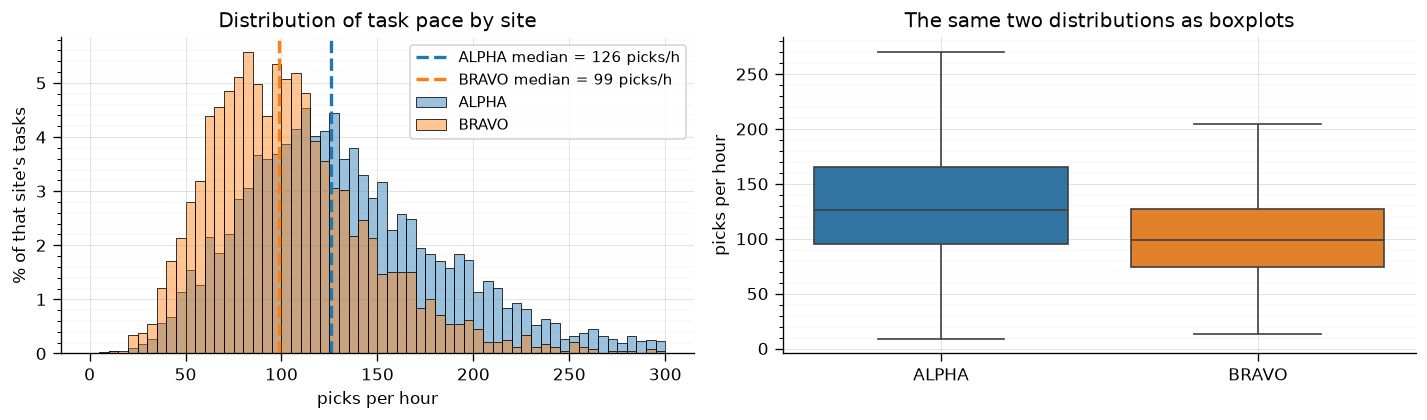

histogram range stops at 300 picks/h and leaves out 52 tasks (0.8%)
boxes hide 165 tasks of 6,474 (2.5%)


In [6]:
# seaborn compares groups from one long table: a "site" column tells them apart
pace_by_site = pd.concat([
    alpha_tasks[["picks_per_hour"]].assign(site="ALPHA"),
    bravo_tasks[["picks_per_hour"]].assign(site="BRAVO"),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), dpi=120)

# --- left: two histograms on the same axes. Two groups -> show the SHAPE ---
for site, color in [("ALPHA", ALPHA_COLOR), ("BRAVO", BRAVO_COLOR)]:
    pace = pace_by_site.loc[pace_by_site["site"] == site, "picks_per_hour"]
    sns.histplot(
        pace,
        bins=60,
        binrange=(0, 300),
        stat="percent",       # percent, not count: the sites differ in size
        color=color,
        alpha=0.45,
        label=site,
        ax=axes[0],
    )
    axes[0].axvline(
        pace.median(),
        color=color,
        ls="--",
        lw=2,
        label=f"{site} median = {pace.median():.0f} picks/h",
    )

axes[0].set_title("Distribution of task pace by site")
axes[0].set_xlabel("picks per hour")
axes[0].set_ylabel("% of that site's tasks")
axes[0].legend(fontsize=9)

# --- right: the same two groups squeezed into boxes ---
sns.boxplot(
    data=pace_by_site,
    x="site",
    y="picks_per_hour",
    hue="site",
    palette={"ALPHA": ALPHA_COLOR, "BRAVO": BRAVO_COLOR},
    legend=False,
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("The same two distributions as boxplots")
axes[1].set_ylabel("picks per hour")
axes[1].set_xlabel("")

for ax in axes:
    make_ax_better(ax, minor="y")

plt.tight_layout()
plt.show()

# both charts cut something, so both owe a number
over_300 = (pace_by_site["picks_per_hour"] > 300).sum()
# one quartile per site, mapped back onto every task of that site
q1_by_site = pace_by_site.groupby("site")["picks_per_hour"].quantile(0.25)
q3_by_site = pace_by_site.groupby("site")["picks_per_hour"].quantile(0.75)
task_q1 = pace_by_site["site"].map(q1_by_site)
task_q3 = pace_by_site["site"].map(q3_by_site)
fence = 1.5 * (task_q3 - task_q1)
is_hidden = (
    (pace_by_site["picks_per_hour"] < task_q1 - fence)
    | (pace_by_site["picks_per_hour"] > task_q3 + fence)
)
hidden = is_hidden.sum()

print(
    f"histogram range stops at 300 picks/h and leaves out {over_300:,} tasks "
    f"({over_300 / len(pace_by_site):.1%})"
)
print(
    f"boxes hide {hidden:,} tasks of {len(pace_by_site):,} "
    f"({hidden / len(pace_by_site):.1%})"
)

✅ **What it means:** BRAVO's whole hill sits to the left of ALPHA's — its typical task really is slower, 99 picks per hour against 126. Notice that the histograms carry more than the boxes do: two shapes with their overlap visible, not two summaries.

⛔ **What it does NOT mean:** that BRAVO's pickers are slower than ALPHA's pickers. Look at the overlap: plenty of BRAVO tasks run faster than plenty of ALPHA tasks. *Averages differ; people overlap.* Whether that gap is bigger than luck is next week's entire lecture.

---

## 4. ❓ "Fine — but which site is better for the business?"

<details>
<summary>🔍 <b>What we'll do</b> — think first, then open</summary>

bring in money. First the value each site moved this week, joining picks to **that site's own** price list.
</details>

In [7]:
def compute_value_moved(site):
    """Total ₽ of goods moved, at this site's own prices."""
    events, info = site["events"], site["info"]
    picks = events[events["event_type"] == "PickCorrectItem"]
    priced_picks = picks.merge(site["prices"], on="item_id")
    print(
        f"{info['warehouse_name']} picks before the price join: {len(picks):,}   "
        f"after: {len(priced_picks):,}"
    )
    return priced_picks["price"].sum()


alpha_value = compute_value_moved(alpha)
bravo_value = compute_value_moved(bravo)

print(
    f"value moved — ALPHA: {alpha_value / 1e6:,.0f}M ₽   "
    f"BRAVO: {bravo_value / 1e6:,.0f}M ₽"
)

ALPHA picks before the price join: 145,904   after: 145,904
BRAVO picks before the price join: 88,074   after: 88,074
value moved — ALPHA: 208M ₽   BRAVO: 117M ₽


Now the labor cost. The pay rules live in the metadata — read them **for both** sites:

In [8]:
print("ALPHA pay per pick:", alpha["info"]["pay_per_pick"], alpha["info"]["currency"])
print("BRAVO pay per pick:", bravo["info"]["pay_per_pick"], bravo["info"]["currency"])
print(
    "ALPHA night hours:",
    alpha["info"]["night_hours"],
    "x",
    alpha["info"]["night_bonus_mult"],
)
print(
    "BRAVO night hours:",
    bravo["info"]["night_hours"],
    "x",
    bravo["info"]["night_bonus_mult"],
)

ALPHA pay per pick: 7.0 RUB
BRAVO pay per pick: 6.0 RUB
ALPHA night hours: [22, 6] x 1.25
BRAVO night hours: [22, 6] x 1.25


**Stop. The rates differ.** Whoever skipped the metadata just computed BRAVO's payroll wrong by 17%. Metadata *is* data — that's why the pickle exists.

Pick pay per site (rate × night bonus, per its own rules). The night window is `[22, 6]`: it starts at 22:00 and ends at 06:00 the next morning. A window that crosses midnight is "after 22 **or** before 6", so the code below uses `|`, not `&`.

In [9]:
def compute_pick_pay(site):
    """Total pick pay for one site, under its own rate and night bonus."""
    events, info = site["events"], site["info"]
    picks = events[events["event_type"] == "PickCorrectItem"]

    hours = picks["event_time"].dt.hour
    # the night window crosses midnight: after 22 OR before 6, so | and not &
    is_night = (hours >= info["night_hours"][0]) | (hours < info["night_hours"][1])
    multiplier = is_night.map({True: info["night_bonus_mult"], False: 1.0})
    return (info["pay_per_pick"] * multiplier).sum()


alpha_pay = compute_pick_pay(alpha)
bravo_pay = compute_pick_pay(bravo)

print(
    f"pick pay — ALPHA: {alpha_pay / 1e3:,.0f}k ₽   "
    f"BRAVO: {bravo_pay / 1e3:,.0f}k ₽"
)

pick pay — ALPHA: 1,129k ₽   BRAVO: 584k ₽


The third pay rule, the per-shift guarantee, is skipped here on purpose. A shift is not a column yet. Defining it is HW1 Part 3.

And the unit-economics metric a CFO would ask for — **labor cost per 1,000 ₽ of value moved:**

pick pay per 1,000 ₽ moved — ALPHA: 5.4 ₽   BRAVO: 5.0 ₽


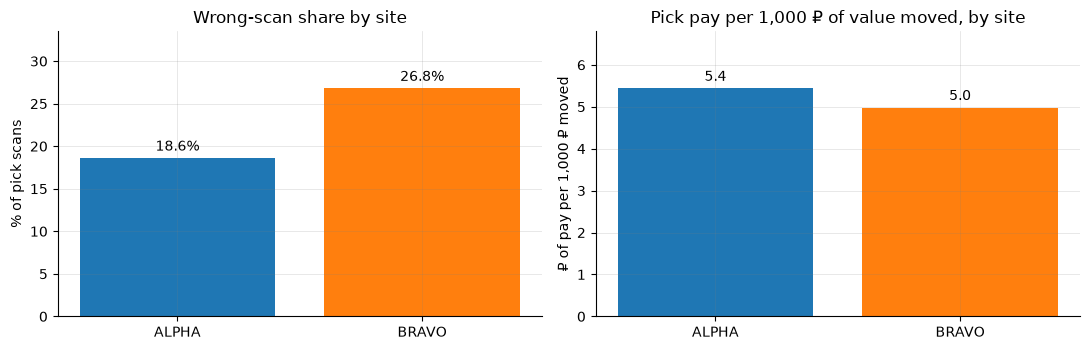

In [10]:
alpha_cost_per_1000 = alpha_pay / alpha_value * 1000
bravo_cost_per_1000 = bravo_pay / bravo_value * 1000

print(
    f"pick pay per 1,000 ₽ moved — ALPHA: {alpha_cost_per_1000:.1f} ₽   "
    f"BRAVO: {bravo_cost_per_1000:.1f} ₽"
)

# the shares are already on the scoreboard, in percent
alpha_wrong_share = alpha_ops["wrong-scan share, %"]
bravo_wrong_share = bravo_ops["wrong-scan share, %"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# --- left: the quality metric ---
ax = axes[0]
bars = ax.bar(
    ["ALPHA", "BRAVO"],
    [alpha_wrong_share, bravo_wrong_share],
    color=[ALPHA_COLOR, BRAVO_COLOR],
)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Wrong-scan share by site")
ax.set_ylabel("% of pick scans")
ax.set_ylim(0, max(alpha_wrong_share, bravo_wrong_share) * 1.25)   # bars start at zero
make_ax_better(ax)

# --- right: the money metric ---
ax = axes[1]
bars = ax.bar(
    ["ALPHA", "BRAVO"],
    [alpha_cost_per_1000, bravo_cost_per_1000],
    color=[ALPHA_COLOR, BRAVO_COLOR],
)
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_title("Pick pay per 1,000 ₽ of value moved, by site")
ax.set_ylabel("₽ of pay per 1,000 ₽ moved")
ax.set_ylim(0, max(alpha_cost_per_1000, bravo_cost_per_1000) * 1.25)
make_ax_better(ax)

plt.tight_layout()
plt.show()

✅ **What it means:** both charts are honest, and they point in opposite directions. BRAVO errs more, picks slower — **and** moves a thousand rubles of goods more cheaply, simply because its labor costs less per pick.

⛔ **What it does NOT mean:** that BRAVO is cheaper, full stop. Notice what the 5.0 ₽ silently omits: the *cost of errors* — returns, re-picks, angry customers. A cheaper wrong pick is still wrong. The number is right; the metric is incomplete.

## 5. So which warehouse is better?

The question has **no answer until someone chooses the metric** — and that choice is a management decision, not a pandas function. Your job as the analyst is to make the choice *visible*: put both numbers on the table, name what each one leaves out, and let the decision be made in the open.

*"What do you tell the manager?"* — that's Part 4 of HW1, and it's graded exactly on this kind of honesty.

## Try it yourself

1. **Night share of picks** at each site — who leans harder on the ×1.25 hours?
2. Median **picks per task** at each site — do the sites batch work differently?
3. Stretch: pay per **active hour** per site. You'll have to define "active hour" — notice how the definition moves the number (hello, HW1 fork).

In [11]:
# your turn


## ⚡ Extras — power tools, not required

The same hidden-task count as in section 3, written as a loop over the groupby object: each turn of the loop hands you one site's name and that site's tasks.

In [12]:
hidden_in_loop = 0
for site, pace in pace_by_site.groupby("site")["picks_per_hour"]:
    q1, q3 = pace.quantile(0.25), pace.quantile(0.75)
    fence = 1.5 * (q3 - q1)
    hidden_in_loop += ((pace < q1 - fence) | (pace > q3 + fence)).sum()
print(f"boxes hide {hidden_in_loop:,} tasks, same as before")

boxes hide 165 tasks, same as before


## Recap

- Same schema + same week = fair comparison; ids are site-local, join within a site.
- Measure both sides with the **same function** (`build_task_table`) — otherwise you are comparing two definitions, not two warehouses.
- Operations scoreboard: BRAVO loses all six rows (27% vs 18% wrong scans, 99 vs 126 picks per hour).
- Distributions overlap even when summaries differ — verdicts from averages alone are fragile.
- **Read the metadata**: the pay rates differ (7 vs 6 ₽) — skipping the pickle breaks the payroll math.
- Unit economics flips the verdict: 5.4 vs 5.0 ₽ per 1,000 ₽ moved.
- Metric choice is a decision. State it, name what it omits, then defend it — in HW1 and in life.